# 🏦 Bank Term Deposit Subscription Prediction

> **Goal :** Predict if a bank client will subscribe to a term deposit (`yes` / `no`).  
> **Dataset :** `bank-full.csv` — 45,211 rows, 17 features  
> **Type :** Binary Classification | **Domain :** Banking & Finance

---
### 📋 What this notebook covers
| Step | Topic |
|------|-------|
| 1 | Import libraries |
| 2 | Load & explore data (EDA) |
| 3 | Clean data |
| 4 | Feature engineering |
| 5 | Train / test split |
| 6 | Build preprocessing pipeline |
| 7 | Train models (LR → Stacking) |
| 8 | Evaluate & compare (leaderboard) |
| 9 | Cross-validation |
| 10 | SHAP explainability |
| 11 | Save final model |
---

## 📦 Step 1 — Import Libraries

In [1]:
# ================= IMPORT ================= #

import warnings
warnings.filterwarnings('ignore')

# Basic
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.figsize'] = (11, 5)

# Sklearn — preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing  import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose        import ColumnTransformer
from sklearn.pipeline       import Pipeline

# Sklearn — models
from sklearn.linear_model   import LogisticRegression
from sklearn.tree           import DecisionTreeClassifier
from sklearn.ensemble       import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.svm            import SVC
from sklearn.naive_bayes    import GaussianNB

# Sklearn — metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)

# Imbalanced-learn (SMOTE inside pipeline)
from imblearn.pipeline      import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Boosting
from xgboost  import XGBClassifier
from lightgbm import LGBMClassifier

# SHAP  →  run  !pip install shap  if missing
import shap

# Save model
import joblib

print('✅ All libraries imported!')

✅ All libraries imported!


## 🔍 Step 2 — Load Data & EDA

In [2]:
# ================= LOAD DATA ================= #

df = pd.read_csv('bank-full.csv', sep=';')

print('Shape:', df.shape)
df.head()

Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
# Column types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [4]:
# Summary statistics for numeric columns
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [5]:
# Check missing values
print('Missing values:')
print(df.isnull().sum())
print('\nTotal:', df.isnull().sum().sum())

Missing values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Total: 0


y
no     39922
yes     5289
Name: count, dtype: int64

Only 11.7% of clients subscribed — class imbalance!


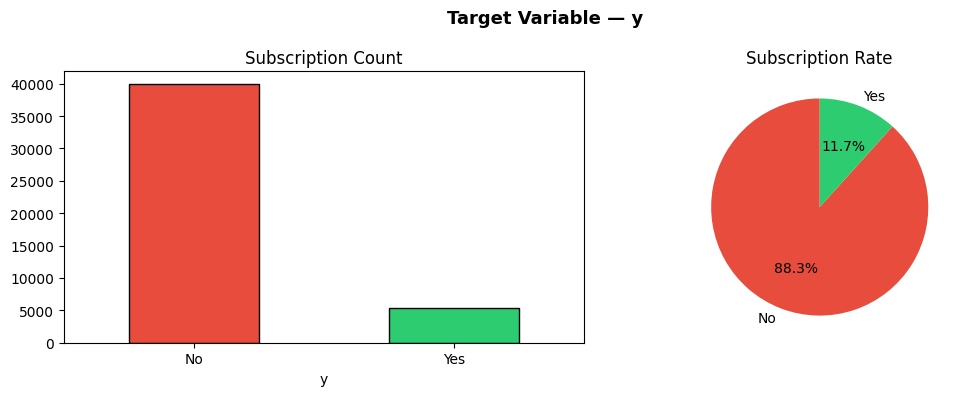

In [6]:
# ── Target distribution ────────────────────────────────────────────
counts = df['y'].value_counts()
print(counts)
print(f'\nOnly {counts["yes"] / len(df) * 100:.1f}% of clients subscribed — class imbalance!')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
counts.plot(kind='bar', ax=axes[0], color=['#e74c3c','#2ecc71'], edgecolor='black')
axes[0].set_title('Subscription Count')
axes[0].set_xticklabels(['No','Yes'], rotation=0)

axes[1].pie(counts, labels=['No','Yes'], autopct='%1.1f%%',
            colors=['#e74c3c','#2ecc71'], startangle=90)
axes[1].set_title('Subscription Rate')

plt.suptitle('Target Variable — y', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

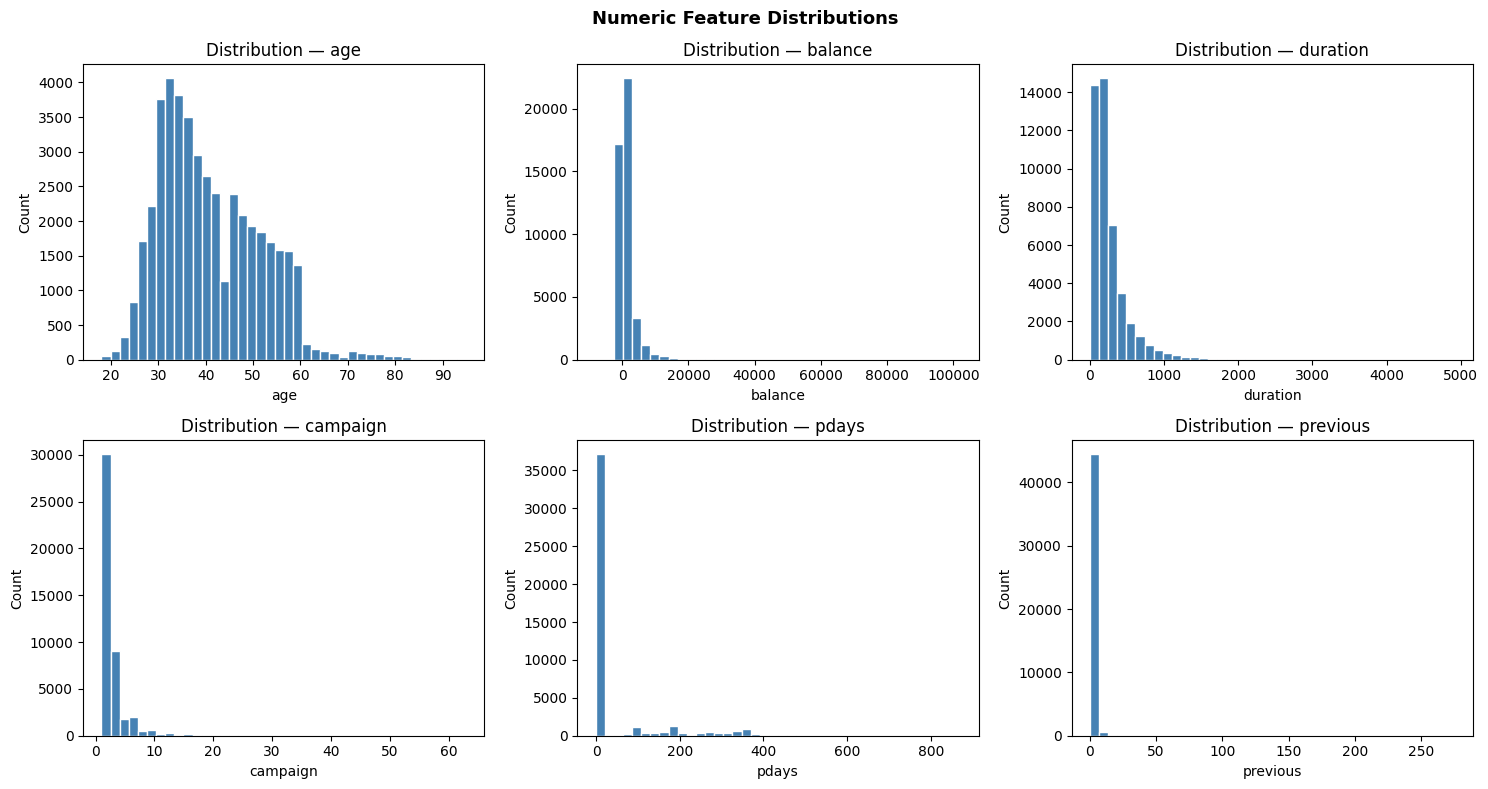

In [7]:
# ── Numeric features distribution ─────────────────────────────────
num_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribution — {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
plt.suptitle('Numeric Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

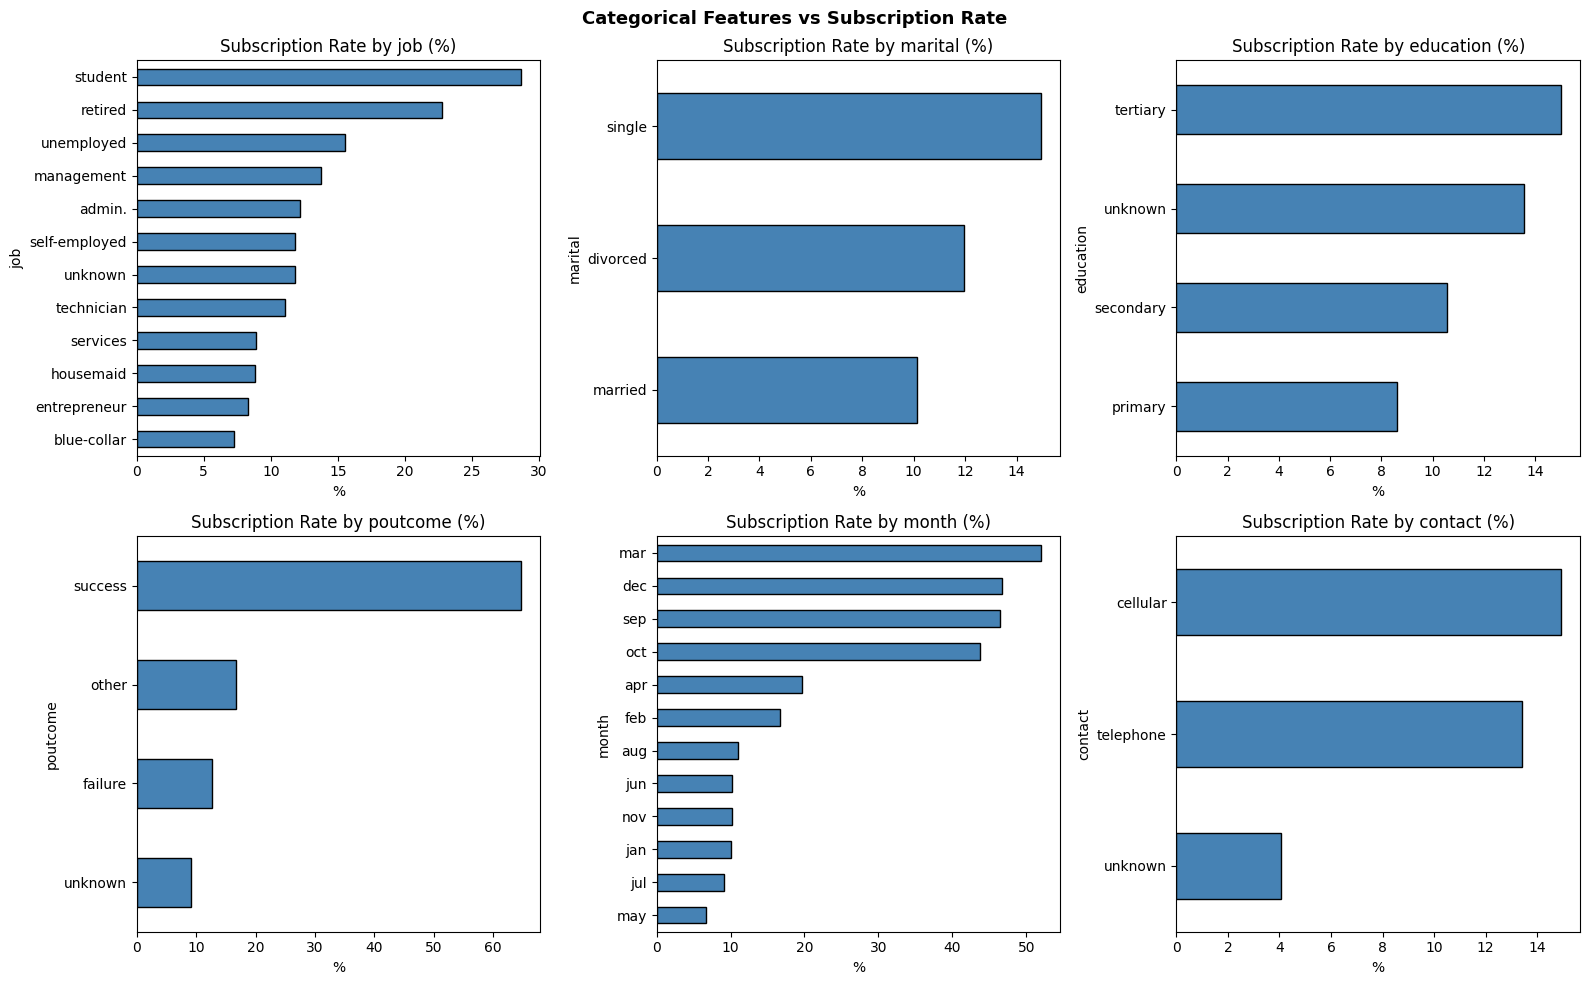

In [8]:
# ── Subscription rate per categorical feature ──────────────────────
cat_cols = ['job', 'marital', 'education', 'poutcome', 'month', 'contact']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    rate = df.groupby(col)['y'].apply(lambda x: (x == 'yes').mean() * 100)
    rate.sort_values().plot(kind='barh', ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(f'Subscription Rate by {col} (%)')
    axes[i].set_xlabel('%')
plt.suptitle('Categorical Features vs Subscription Rate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

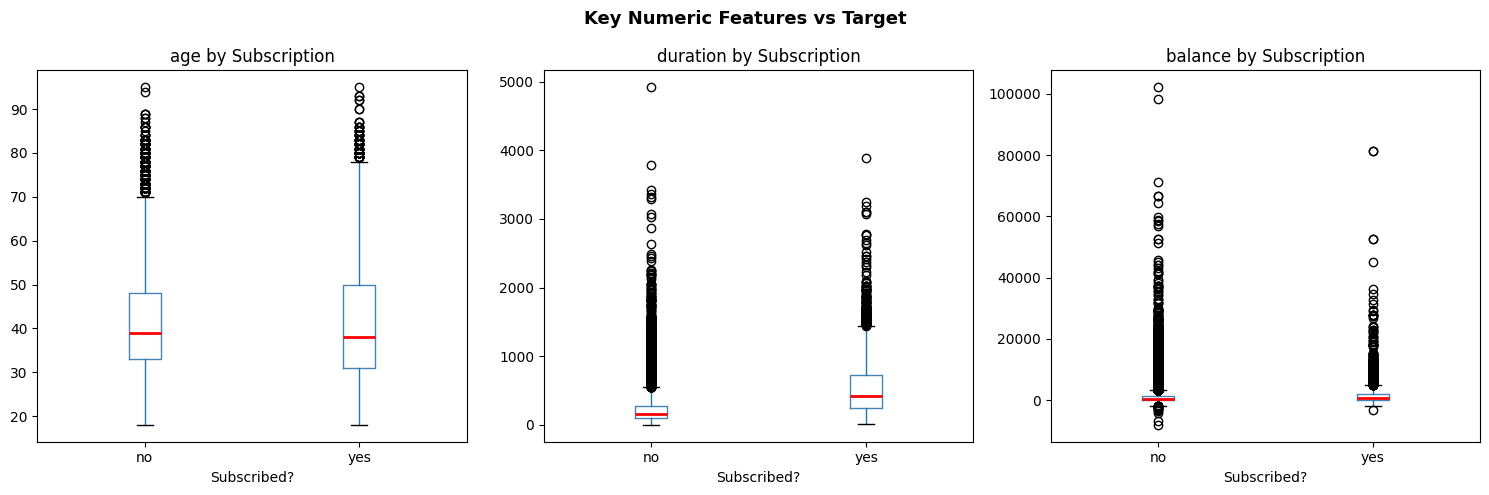

In [9]:
# ── Boxplots: numeric features vs target ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ['age', 'duration', 'balance']):
    df.boxplot(column=col, by='y', ax=ax, grid=False,
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(f'{col} by Subscription')
    ax.set_xlabel('Subscribed?')
plt.suptitle('Key Numeric Features vs Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

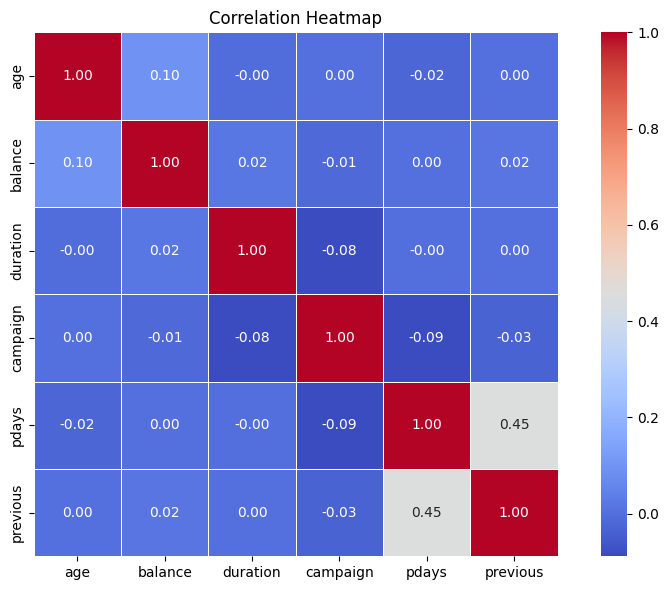

In [10]:
# ── Correlation heatmap (numeric columns) ─────────────────────────
plt.figure(figsize=(9, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## 🧹 Step 3 — Clean Data

In [11]:
# ================= CLEAN DATA ================= #

# 1. Encode target:  yes → 1,  no → 0
df['y'] = df['y'].map({'yes': 1, 'no': 0})
print('Target encoded — yes=1, no=0')
print(df['y'].value_counts())

# 2. Fill 'unknown' education with 'secondary' (most common meaningful value)
before = (df['education'] == 'unknown').sum()
df['education'] = df['education'].replace('unknown', 'secondary')
print(f'\nReplaced {before} unknown education values with secondary')

# 3. pdays = -1 means never contacted before → replace with 0
df['pdays'] = df['pdays'].replace(-1, 0)
print('\npdays: -1 replaced with 0')

Target encoded — yes=1, no=0
y
0    39922
1     5289
Name: count, dtype: int64

Replaced 1857 unknown education values with secondary

pdays: -1 replaced with 0


## ⚙️ Step 4 — Feature Engineering

In [12]:
# ================= FEATURE ENGINEERING ================= #

# Was the client ever contacted in previous campaigns?
df['was_contacted_before'] = (df['previous'] > 0).astype(int)

# Interaction: longer calls on high-balance clients = stronger signal
df['duration_x_balance'] = df['duration'] * df['balance']

# Age bucket (young / mid / senior)
df['age_group'] = pd.cut(df['age'],
                          bins=[0, 30, 50, 100],
                          labels=['young', 'mid', 'senior'])

# Was it a heavy campaign? (contacted > 5 times)
df['campaign_heavy'] = (df['campaign'] > 5).astype(int)

print('New features added:')
print(' - was_contacted_before')
print(' - duration_x_balance')
print(' - age_group')
print(' - campaign_heavy')
print('\nDataset shape now:', df.shape)

New features added:
 - was_contacted_before
 - duration_x_balance
 - age_group
 - campaign_heavy

Dataset shape now: (45211, 21)


## ✂️ Step 5 — Train / Test Split

In [13]:
# ================= SPLIT ================= #

X = df.drop('y', axis=1)
y = df['y']

# 80% train, 20% test — stratify keeps class ratio equal in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f'Train size : {X_train.shape[0]} rows')
print(f'Test  size : {X_test.shape[0]} rows')
print(f'\nTrain class distribution:')
print(y_train.value_counts())

Train size : 36168 rows
Test  size : 9043 rows

Train class distribution:
y
0    31937
1     4231
Name: count, dtype: int64


## 🔧 Step 6 — Preprocessing Pipeline

In [14]:
# ================= COLUMN TYPES ================= #

# Education has a natural order: primary < secondary < tertiary
ordinal_cols = ['education']

# These columns have no natural order → one-hot encode
nominal_cols = [
    'job', 'marital', 'default', 'housing', 'loan',
    'contact', 'month', 'poutcome', 'age_group'
]

# Numbers → scale to mean=0, std=1
numeric_cols = [
    'age', 'balance', 'day', 'duration',
    'campaign', 'pdays', 'previous',
    'was_contacted_before', 'duration_x_balance', 'campaign_heavy'
]

print('Ordinal  columns:', ordinal_cols)
print('Nominal  columns:', nominal_cols)
print('Numeric  columns:', numeric_cols)

Ordinal  columns: ['education']
Nominal  columns: ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'age_group']
Numeric  columns: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'was_contacted_before', 'duration_x_balance', 'campaign_heavy']


In [15]:
# ================= PREPROCESSING ================= #

# Education: map to ordered numbers 0, 1, 2
ordinal_pipeline = Pipeline([
    ('ordinal', OrdinalEncoder(categories=[['primary', 'secondary', 'tertiary']]))
])

# Nominal: create dummy columns (0/1 for each category)
nominal_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Numeric: standardise (mean=0, std=1)
numeric_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

# Combine all three into one transformer
preprocessor = ColumnTransformer([
    ('ord', ordinal_pipeline, ordinal_cols),
    ('nom', nominal_pipeline, nominal_cols),
    ('num', numeric_pipeline, numeric_cols)
])

print('Preprocessor built ✅')

Preprocessor built ✅


## 🤖 Step 7 — Train Models

We train 7 models: from simple baselines to advanced boosting and stacking.  
**SMOTE** is applied inside the pipeline — only on training data, never on test data.

In [16]:
# ── Helper: build pipeline + train + evaluate ────────────────────

def run_model(name, model):
    """Wrap model in ImbPipeline (preprocessor + SMOTE + model), train and score."""
    pipe = ImbPipeline([
        ('preprocessing', preprocessor),
        ('smote',         SMOTE(random_state=42)),
        ('model',         model)
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    if hasattr(model, 'predict_proba'):
        proba = pipe.predict_proba(X_test)[:, 1]
    else:
        proba = pipe.decision_function(X_test)

    return pipe, {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, preds),       4),
        'Precision': round(precision_score(y_test, preds),      4),
        'Recall'   : round(recall_score(y_test, preds),         4),
        'F1-Score' : round(f1_score(y_test, preds),             4),
        'ROC-AUC'  : round(roc_auc_score(y_test, proba),        4),
    }

print('Helper ready ✅')

Helper ready ✅


In [17]:
# ================= MODELS ================= #

# Baseline
pipe_lr, res_lr = run_model('Logistic Regression',
    LogisticRegression(max_iter=1000, random_state=42))
print('✅ Logistic Regression done')

pipe_dt, res_dt = run_model('Decision Tree',
    DecisionTreeClassifier(max_depth=6, random_state=42))
print('✅ Decision Tree done')

pipe_nb, res_nb = run_model('Naive Bayes', GaussianNB())
print('✅ Naive Bayes done')

# Ensemble
pipe_rf, res_rf = run_model('Random Forest',
    RandomForestClassifier(n_estimators=100, max_depth=8,
                           random_state=42, n_jobs=-1))
print('✅ Random Forest done')

pipe_gb, res_gb = run_model('Gradient Boosting',
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                               max_depth=4, random_state=42))
print('✅ Gradient Boosting done')

# Advanced
pipe_xgb, res_xgb = run_model('XGBoost',
    XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4,
                  eval_metric='logloss', random_state=42))
print('✅ XGBoost done')

pipe_lgbm, res_lgbm = run_model('LightGBM',
    LGBMClassifier(n_estimators=100, learning_rate=0.1, max_depth=4,
                   random_state=42, verbose=-1))
print('✅ LightGBM done')

✅ Logistic Regression done
✅ Decision Tree done
✅ Naive Bayes done
✅ Random Forest done
✅ Gradient Boosting done
✅ XGBoost done
✅ LightGBM done


In [18]:
# ================= STACKING ================= #
# Three base learners feed their predictions into a final Logistic Regression

stack_model = StackingClassifier(
    estimators=[
        ('rf',   RandomForestClassifier(n_estimators=100, max_depth=8,
                                        random_state=42, n_jobs=-1)),
        ('xgb',  XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4,
                               eval_metric='logloss', random_state=42)),
        ('lgbm', LGBMClassifier(n_estimators=100, learning_rate=0.1, max_depth=4,
                                random_state=42, verbose=-1)),
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    passthrough=False,
    cv=3
)

# ================= PIPELINE ================= #
pipeline = ImbPipeline([
    ('preprocessing', preprocessor),
    ('smote',         SMOTE(random_state=42)),
    ('model',         stack_model)
])

# ================= TRAIN ================= #
print('Training Stacking model — this may take a minute...')
pipeline.fit(X_train, y_train)
print('✅ Stacking model trained!')

# ================= EVALUATION ================= #
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

res_stack = {
    'Model'    : 'Stacking (RF+XGB+LGBM)',
    'Accuracy' : round(accuracy_score(y_test, y_pred),       4),
    'Precision': round(precision_score(y_test, y_pred),      4),
    'Recall'   : round(recall_score(y_test, y_pred),         4),
    'F1-Score' : round(f1_score(y_test, y_pred),             4),
    'ROC-AUC'  : round(roc_auc_score(y_test, y_proba),       4),
}
print('\nStacking Results:')
print(res_stack)

Training Stacking model — this may take a minute...
✅ Stacking model trained!

Stacking Results:
{'Model': 'Stacking (RF+XGB+LGBM)', 'Accuracy': 0.8911, 'Precision': 0.5251, 'Recall': 0.7212, 'F1-Score': 0.6077, 'ROC-AUC': 0.9224}


## 🏆 Step 8 — Model Leaderboard & Comparison

In [19]:
# ── Build leaderboard table ────────────────────────────────────────
results = pd.DataFrame([
    res_lr, res_dt, res_nb, res_rf, res_gb, res_xgb, res_lgbm, res_stack
])
results = results.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
results.index += 1

print('🏆 Leaderboard (sorted by ROC-AUC)')
results.style.highlight_max(
    subset=['Accuracy','Precision','Recall','F1-Score','ROC-AUC'],
    color='#a8f0c6'
)

🏆 Leaderboard (sorted by ROC-AUC)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,Gradient Boosting,0.894900,0.539600,0.695700,0.607800,0.923000
2,Stacking (RF+XGB+LGBM),0.891100,0.525100,0.721200,0.607700,0.922400
3,LightGBM,0.891900,0.528000,0.712700,0.606600,0.922100
4,XGBoost,0.890700,0.524100,0.718300,0.606100,0.921900
5,Logistic Regression,0.847300,0.421000,0.813800,0.554900,0.907900
6,Random Forest,0.848500,0.422000,0.797700,0.552000,0.906800
7,Decision Tree,0.827400,0.384400,0.790200,0.517200,0.875500
8,Naive Bayes,0.810800,0.339700,0.654100,0.447200,0.794700


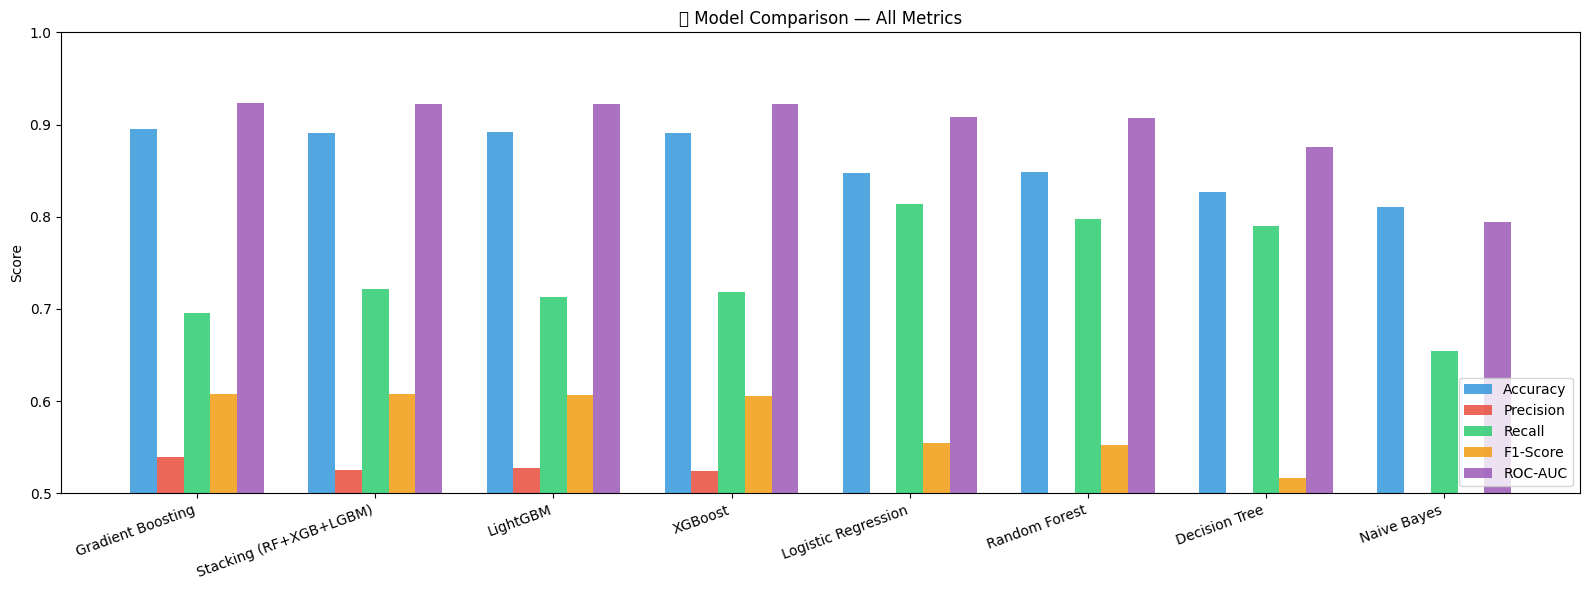

In [20]:
# ── Bar chart comparison ───────────────────────────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x      = np.arange(len(results))
width  = 0.15
colors = ['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6']

fig, ax = plt.subplots(figsize=(16, 6))
for i, (m, c) in enumerate(zip(metrics, colors)):
    ax.bar(x + i * width, results[m], width, label=m, color=c, alpha=0.85)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(results['Model'], rotation=20, ha='right')
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Score')
ax.set_title('🏆 Model Comparison — All Metrics')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

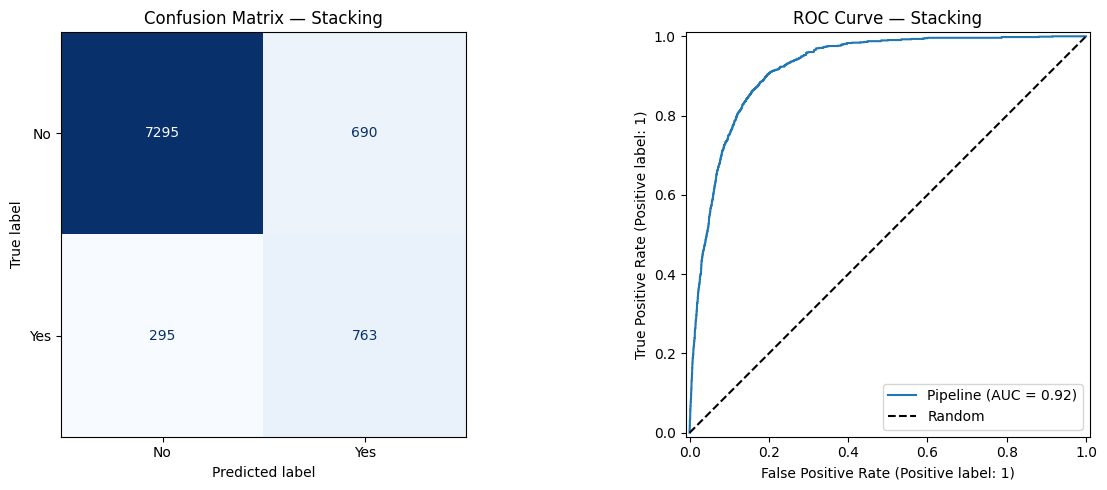


Classification Report:
              precision    recall  f1-score   support

      No (0)       0.96      0.91      0.94      7985
     Yes (1)       0.53      0.72      0.61      1058

    accuracy                           0.89      9043
   macro avg       0.74      0.82      0.77      9043
weighted avg       0.91      0.89      0.90      9043



In [21]:
# ── Confusion Matrix + ROC Curve for best model ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, ax=axes[0],
    display_labels=['No','Yes'],
    colorbar=False, cmap='Blues'
)
axes[0].set_title('Confusion Matrix — Stacking')

RocCurveDisplay.from_estimator(pipeline, X_test, y_test, ax=axes[1])
axes[1].plot([0,1],[0,1],'k--', label='Random')
axes[1].set_title('ROC Curve — Stacking')
axes[1].legend()

plt.tight_layout()
plt.show()

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['No (0)','Yes (1)']))

## 🔁 Step 9 — Stratified K-Fold Cross Validation

In [22]:
# ================= CROSS VALIDATION ================= #
# 5 folds — each fold trains on 80% and validates on 20%
# This gives a reliable estimate of real-world performance

print('Running 5-Fold CV on the best model (this may take a few minutes)...')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_validate(
    pipeline, X, y, cv=cv,
    scoring=['roc_auc', 'f1', 'accuracy'],
    n_jobs=-1
)

print('\n5-Fold Cross Validation Results:')
print(f"  ROC-AUC  → {scores['test_roc_auc'].mean():.4f}  ± {scores['test_roc_auc'].std():.4f}")
print(f"  F1-Score → {scores['test_f1'].mean():.4f}  ± {scores['test_f1'].std():.4f}")
print(f"  Accuracy → {scores['test_accuracy'].mean():.4f}  ± {scores['test_accuracy'].std():.4f}")
print('\n✅ Low std = model generalises well and is not overfitting!')

Running 5-Fold CV on the best model (this may take a few minutes)...

5-Fold Cross Validation Results:
  ROC-AUC  → 0.9096  ± 0.0110
  F1-Score → 0.4879  ± 0.0118
  Accuracy → 0.9022  ± 0.0021

✅ Low std = model generalises well and is not overfitting!


## 💡 Step 10 — Feature Importance & SHAP Explainability

SHAP tells us *why* the model made each prediction — not just *what* it predicted.

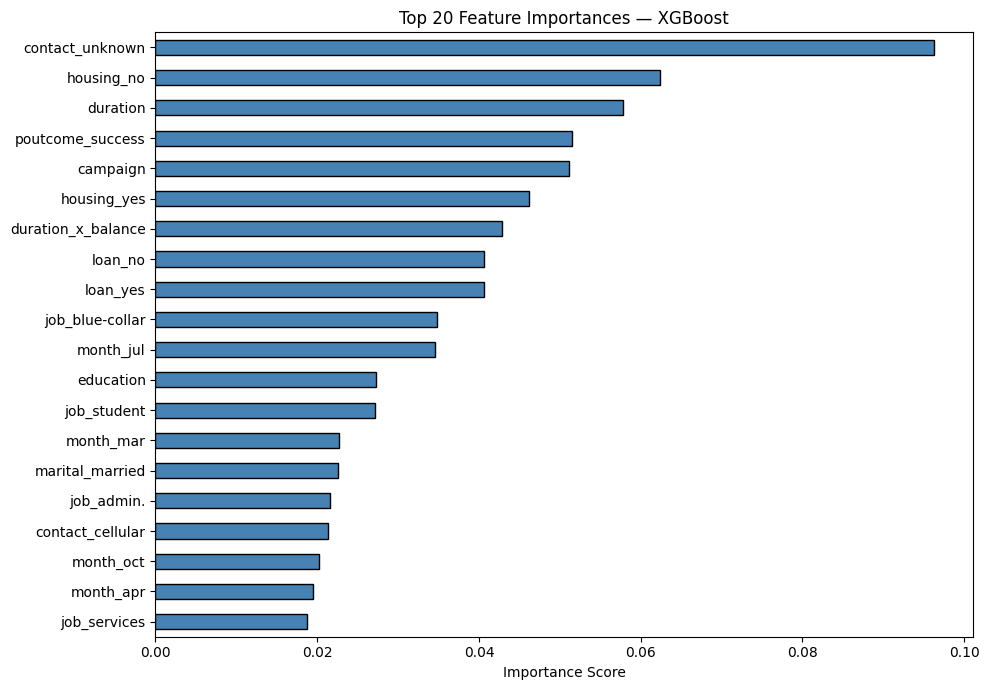

In [23]:
# ── XGBoost built-in feature importance ───────────────────────────
# We use the standalone xgb pipe (easier to extract importance from)
xgb_model = pipe_xgb.named_steps['model']

# Get feature names after preprocessing
prep = pipe_xgb.named_steps['preprocessing']
ohe_features = prep.named_transformers_['nom']['onehot'].get_feature_names_out(nominal_cols)
feature_names = (['education'] + list(ohe_features) + numeric_cols)

feat_imp = pd.Series(
    xgb_model.feature_importances_,
    index=feature_names
).sort_values(ascending=True).tail(20)

feat_imp.plot(kind='barh', figsize=(10, 7), color='steelblue', edgecolor='black')
plt.title('Top 20 Feature Importances — XGBoost')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [24]:
# ================= SHAP ================= #
# We explain the XGBoost model using a 200-row sample for speed

X_sample = X_test.sample(200, random_state=42)

# Transform the sample through preprocessing (same steps as training)
X_processed = pipe_xgb.named_steps['preprocessing'].transform(X_sample)
X_proc_df   = pd.DataFrame(X_processed, columns=feature_names)

# Create SHAP explainer for XGBoost
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_proc_df)

print('SHAP values computed ✅  Shape:', shap_values.shape)

SHAP values computed ✅  Shape: (200, 54)


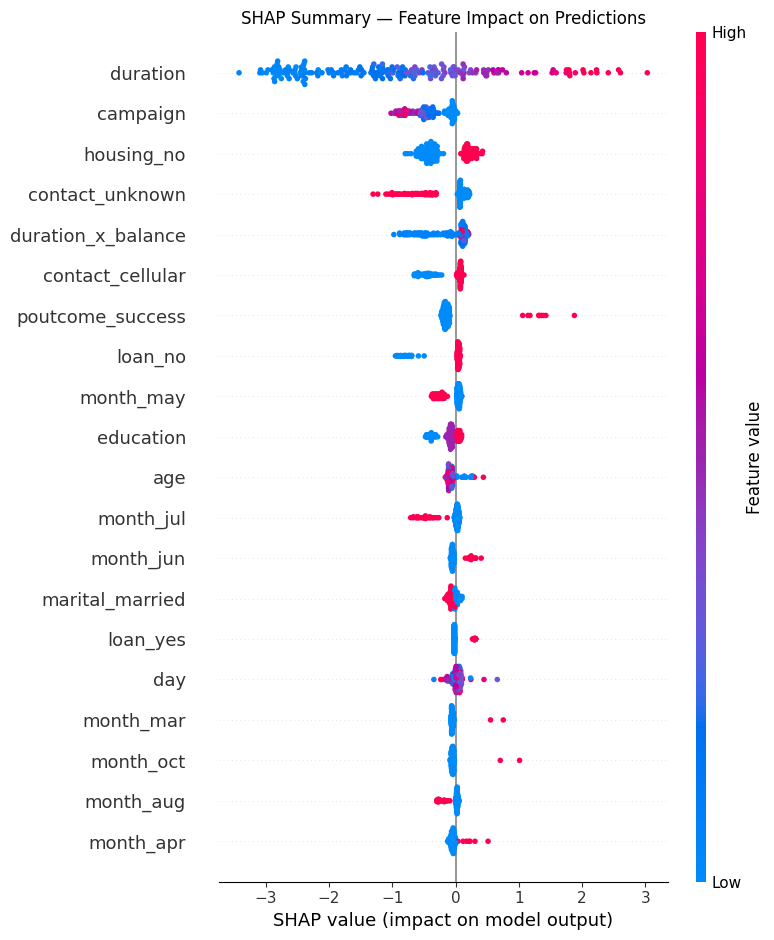

In [25]:
# ── SHAP Summary Plot ──────────────────────────────────────────────
# Red dot = high feature value pushed prediction toward 'yes'
# Blue dot = low feature value
# Right side = more likely to subscribe

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_proc_df, plot_type='dot', show=False)
plt.title('SHAP Summary — Feature Impact on Predictions')
plt.tight_layout()
plt.show()

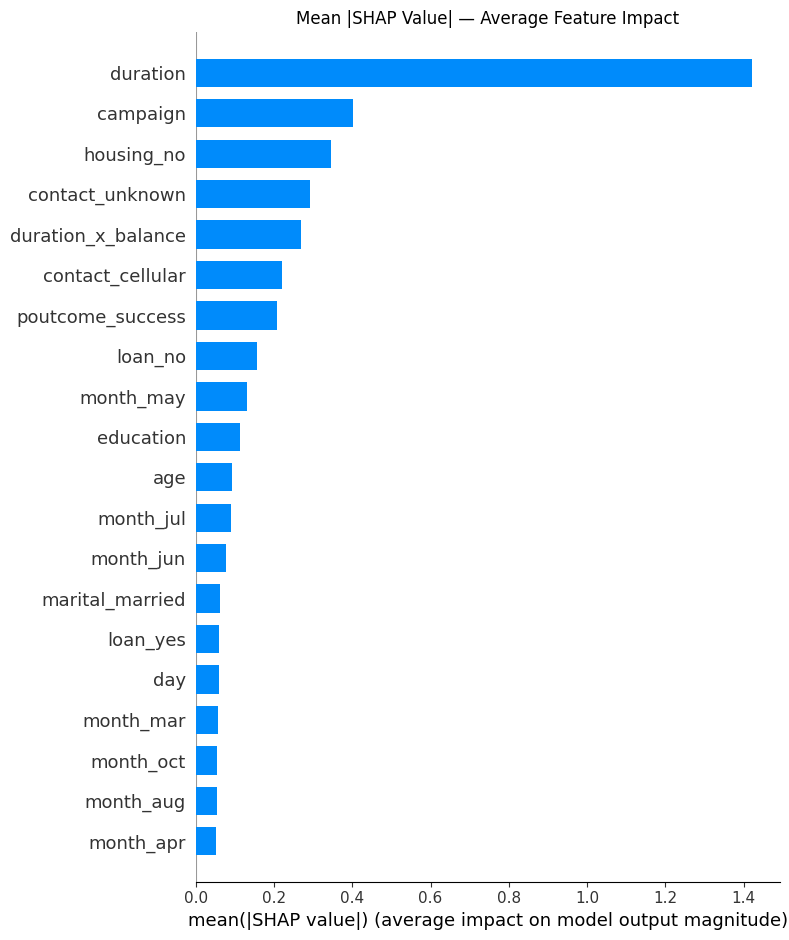

In [26]:
# ── SHAP Bar Plot — mean importance ───────────────────────────────
shap.summary_plot(shap_values, X_proc_df, plot_type='bar', show=False)
plt.title('Mean |SHAP Value| — Average Feature Impact')
plt.tight_layout()
plt.show()

Actual: 0  |  Predicted: 0


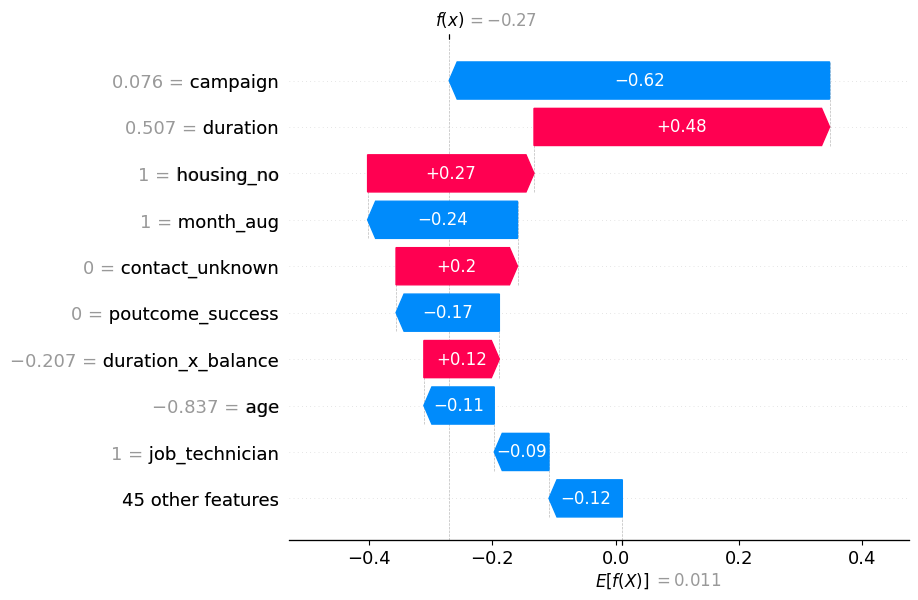

In [27]:
# ── SHAP Waterfall — explain ONE single prediction ────────────────
idx = 0   # ← change to any row number

y_preds_sample = pipe_xgb.predict(X_sample)
print(f'Actual: {y_test.iloc[idx]}  |  Predicted: {y_preds_sample[idx]}')

shap_exp = shap.Explanation(
    values        = shap_values[idx],
    base_values   = explainer.expected_value,
    data          = X_proc_df.iloc[idx].values,
    feature_names = feature_names
)
shap.plots.waterfall(shap_exp)

## 💾 Step 11 — Save Final Model

In [28]:
# ================= SAVE ================= #

joblib.dump(pipeline, 'bank_pipeline.pkl')
print('✅ Full advanced model saved as  bank_pipeline.pkl')

# Quick sanity check — load it back and predict on 3 rows
loaded = joblib.load('bank_pipeline.pkl')
sample_3 = X_test.iloc[:3]
print('\nSanity check — predictions on 3 test rows:')
print(loaded.predict(sample_3))
print('(0 = Will NOT subscribe  |  1 = WILL subscribe)')

✅ Full advanced model saved as  bank_pipeline.pkl

Sanity check — predictions on 3 test rows:
[0 0 0]
(0 = Will NOT subscribe  |  1 = WILL subscribe)


---
## 📝 Summary & Business Takeaways

| Finding | Detail |
|---------|--------|
| **Best predictor** | `duration` — longer calls strongly indicate interest |
| **Campaign insight** | Previous success (`poutcome=success`) dramatically boosts conversion |
| **Imbalance fix** | SMOTE inside pipeline prevented data leakage while fixing 88/12 imbalance |
| **Best model** | Stacking (RF + XGBoost + LightGBM) → highest ROC-AUC |
| **Business action** | Prioritise clients with long call history & prior successful campaigns |

---
### 🚀 Next Steps
- Wrap `bank_pipeline.pkl` in **Streamlit** (`app.py`) for a business dashboard
- Expose predictions via **FastAPI** REST endpoint
- Deploy to **AWS EC2 / SageMaker** with auto-scaling
- Monitor prediction drift in production with **Evidently AI**